<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading datasets...

PART A: K-NN Implementation
K=1, euclidean: Accuracy=0.711
K=1, manhattan: Accuracy=0.711
K=3, euclidean: Accuracy=0.756
K=3, manhattan: Accuracy=0.756
K=5, euclidean: Accuracy=0.778
K=5, manhattan: Accuracy=0.800
K=7, euclidean: Accuracy=0.800
K=7, manhattan: Accuracy=0.778
K=9, euclidean: Accuracy=0.800
K=9, manhattan: Accuracy=0.778

PART B: Naive Bayes Implementation
Multinomial NB Accuracy: 0.984
Gaussian NB Accuracy: 0.865

Probability comparison (first 3 samples):
Sample 1: MNB[ham=1.000, spam=0.000] | GNB[ham=0.478, spam=0.522]
Sample 2: MNB[ham=1.000, spam=0.000] | GNB[ham=0.497, spam=0.503]
Sample 3: MNB[ham=1.000, spam=0.000] | GNB[ham=0.671, spam=0.329]

PART C: Algorithm Comparison

Algorithm Comparison Table:
           Algorithm Accuracy Precision Recall Train Time (ms) Pred Time (ms)
         K-NN (Iris)    0.778     0.778  0.778            3.73           5.07
  Gaussian NB (Iris)    0.822     0.834  0.822            1.97           0.62
          K-

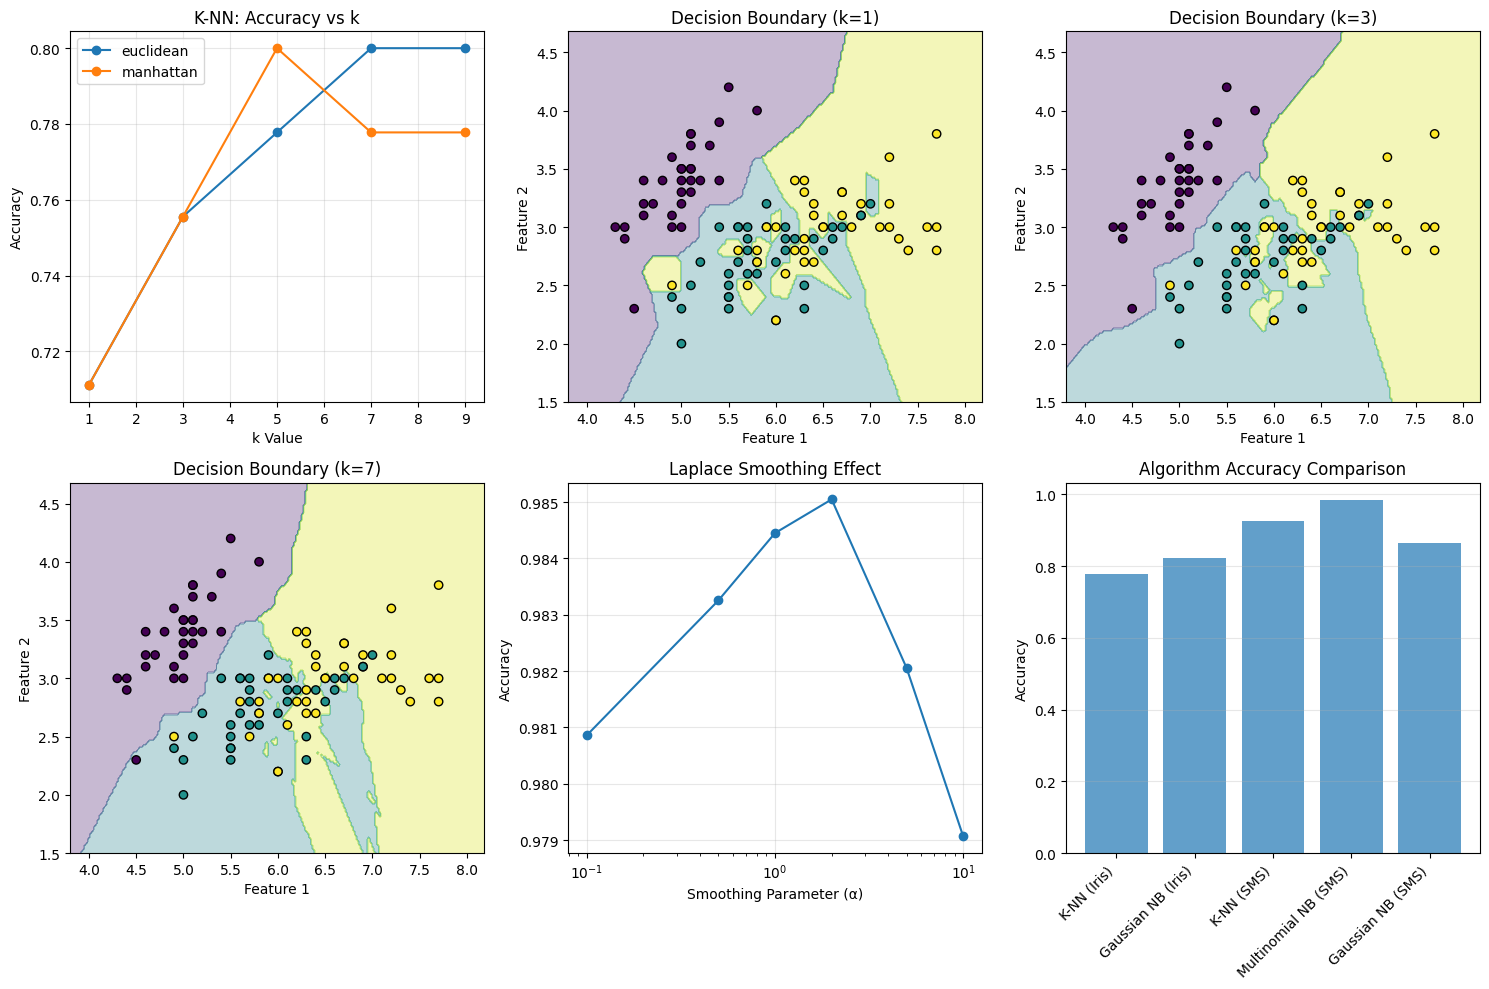

In [1]:
# EXP-6 (IN-LAB): K-NN and Naive Bayes Classifiers
# Part A: K-NN on Iris (different k + distance metrics + accuracy plot + decision boundaries)
# Part B: Naive Bayes on SMS Spam (MultinomialNB + GaussianNB + probability outputs + Laplace smoothing)
# Part C: Comparison (accuracy/precision/recall + training & prediction time)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import string

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ----------------------------
# Load datasets
# ----------------------------
print("Loading datasets...")
iris = load_iris()

df_sms = pd.read_csv(
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
    sep="\t",
    names=["label", "message"]
)

# ==========================================================
# PART A: K-NN Implementation (Iris)
# ==========================================================
print("\n" + "=" * 50)
print("PART A: K-NN Implementation")
print("=" * 50)

# Prepare Iris data (use first two features for plotting decision boundaries)
X_iris = iris.data[:, :2]
y_iris = iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

k_values = [1, 3, 5, 7, 9]
results_knn = []

for k in k_values:
    for metric in ["euclidean", "manhattan"]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_i, y_train_i)
        acc = accuracy_score(y_test_i, knn.predict(X_test_i))
        results_knn.append([k, metric, acc])
        print(f"K={k}, {metric}: Accuracy={acc:.3f}")

# Plot accuracy vs k + decision boundaries
plt.figure(figsize=(15, 10))

# Accuracy vs k plot
plt.subplot(2, 3, 1)
df_knn = pd.DataFrame(results_knn, columns=["k", "metric", "accuracy"])
for metric in ["euclidean", "manhattan"]:
    temp = df_knn[df_knn["metric"] == metric]
    plt.plot(temp["k"], temp["accuracy"], marker="o", label=metric)

plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.title("K-NN: Accuracy vs k")
plt.legend()
plt.grid(True, alpha=0.3)

# Decision boundaries for k = 1, 3, 7
for idx, k in enumerate([1, 3, 7], start=2):
    plt.subplot(2, 3, idx)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_i, y_train_i)

    x_min, x_max = X_train_i[:, 0].min() - 0.5, X_train_i[:, 0].max() + 0.5
    y_min, y_max = X_train_i[:, 1].min() - 0.5, X_train_i[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train_i[:, 0], X_train_i[:, 1], c=y_train_i, edgecolor="k")
    plt.title(f"Decision Boundary (k={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

# ==========================================================
# PART B: Naive Bayes Implementation (SMS Spam)
# ==========================================================
print("\n" + "=" * 50)
print("PART B: Naive Bayes Implementation")
print("=" * 50)

# Preprocess SMS data
df_sms["label"] = df_sms["label"].map({"ham": 0, "spam": 1})
df_sms["processed"] = (
    df_sms["message"]
    .str.lower()
    .str.replace(f"[{string.punctuation}]", "", regex=True)
)

# Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df_sms["processed"], df_sms["label"], test_size=0.3, random_state=42
)

# Vectorize text
vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train_s)
X_test_vec = vectorizer.transform(X_test_s)

# Create simple numerical features for Gaussian NB
X_train_num = np.array([[len(msg), len(msg.split())] for msg in X_train_s])
X_test_num = np.array([[len(msg), len(msg.split())] for msg in X_test_s])

# Multinomial NB
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train_s)
y_pred_mnb = mnb.predict(X_test_vec)
acc_mnb = accuracy_score(y_test_s, y_pred_mnb)
print(f"Multinomial NB Accuracy: {acc_mnb:.3f}")

# Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train_num, y_train_s)
y_pred_gnb = gnb.predict(X_test_num)
acc_gnb = accuracy_score(y_test_s, y_pred_gnb)
print(f"Gaussian NB Accuracy: {acc_gnb:.3f}")

# Laplace smoothing effect
plt.subplot(2, 3, 5)
alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
acc_smooth = []

for alpha in alphas:
    mnb_smooth = MultinomialNB(alpha=alpha)
    mnb_smooth.fit(X_train_vec, y_train_s)
    pred = mnb_smooth.predict(X_test_vec)
    acc_smooth.append(accuracy_score(y_test_s, pred))

plt.plot(alphas, acc_smooth, marker="o")
plt.xscale("log")
plt.xlabel("Smoothing Parameter (α)")
plt.ylabel("Accuracy")
plt.title("Laplace Smoothing Effect")
plt.grid(True, alpha=0.3)

# Compare probability outputs
print("\nProbability comparison (first 3 samples):")
probs_mnb = mnb.predict_proba(X_test_vec)[:3]
probs_gnb = gnb.predict_proba(X_test_num)[:3]
for i in range(3):
    print(
        f"Sample {i+1}: "
        f"MNB[ham={probs_mnb[i][0]:.3f}, spam={probs_mnb[i][1]:.3f}] | "
        f"GNB[ham={probs_gnb[i][0]:.3f}, spam={probs_gnb[i][1]:.3f}]"
    )

# ==========================================================
# PART C: Comparison (Accuracy/Precision/Recall + Times)
# ==========================================================
print("\n" + "=" * 50)
print("PART C: Algorithm Comparison")
print("=" * 50)

def evaluate_algo(model, X_train, X_test, y_train, y_test, name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    return {
        "Algorithm": name,
        "Accuracy": f"{acc:.3f}",
        "Precision": f"{prec:.3f}",
        "Recall": f"{rec:.3f}",
        "Train Time (ms)": f"{train_time * 1000:.2f}",
        "Pred Time (ms)": f"{pred_time * 1000:.2f}",
    }

results = []

# Compare on Iris (K-NN vs Gaussian NB)
results.append(evaluate_algo(
    KNeighborsClassifier(n_neighbors=5),
    X_train_i, X_test_i, y_train_i, y_test_i,
    "K-NN (Iris)"
))
results.append(evaluate_algo(
    GaussianNB(),
    X_train_i, X_test_i, y_train_i, y_test_i,
    "Gaussian NB (Iris)"
))

# Compare on SMS (K-NN vs Multinomial NB vs Gaussian NB)
results.append(evaluate_algo(
    KNeighborsClassifier(n_neighbors=5),
    X_train_vec.toarray(), X_test_vec.toarray(), y_train_s, y_test_s,
    "K-NN (SMS)"
))
results.append(evaluate_algo(
    MultinomialNB(),
    X_train_vec, X_test_vec, y_train_s, y_test_s,
    "Multinomial NB (SMS)"
))
results.append(evaluate_algo(
    GaussianNB(),
    X_train_num, X_test_num, y_train_s, y_test_s,
    "Gaussian NB (SMS)"
))

df_comparison = pd.DataFrame(results)
print("\nAlgorithm Comparison Table:")
print(df_comparison.to_string(index=False))

# Bar chart of accuracies
plt.subplot(2, 3, 6)
x_pos = np.arange(len(results))
acc_values = [float(r["Accuracy"]) for r in results]
plt.bar(x_pos, acc_values, alpha=0.7)
plt.xticks(x_pos, [r["Algorithm"] for r in results], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Algorithm Accuracy Comparison")
plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [2]:
# EXP-6 (POST-LAB): Weighted K-NN, Bernoulli Naive Bayes, Voting Classifier,
# GridSearchCV Hyperparameter Tuning, Misclassified Instance Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import VotingClassifier

# ----------------------------
# Load datasets
# ----------------------------
iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target

df_sms = pd.read_csv(
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
    sep="\t",
    names=["label", "message"]
)

# Preprocess SMS
df_sms["label"] = df_sms["label"].map({"ham": 0, "spam": 1})
df_sms["processed"] = (
    df_sms["message"]
    .str.lower()
    .str.replace(f"[{string.punctuation}]", "", regex=True)
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df_sms["processed"], df_sms["label"], test_size=0.3, random_state=42
)

# Vectorize SMS
vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train_s)
X_test_vec = vectorizer.transform(X_test_s)

# Bernoulli NB needs binary features
X_train_bin = (X_train_vec > 0).astype(int)
X_test_bin = (X_test_vec > 0).astype(int)

# Split Iris
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

# ==========================================================
# 1) Weighted K-NN
# ==========================================================
print("=" * 60)
print("POST-LAB 1: Weighted K-NN")
print("=" * 60)

knn_uniform = KNeighborsClassifier(n_neighbors=5, weights="uniform")
knn_distance = KNeighborsClassifier(n_neighbors=5, weights="distance")

knn_uniform.fit(X_train_i, y_train_i)
knn_distance.fit(X_train_i, y_train_i)

acc_u = accuracy_score(y_test_i, knn_uniform.predict(X_test_i))
acc_d = accuracy_score(y_test_i, knn_distance.predict(X_test_i))

print(f"KNN (uniform weights)  Accuracy: {acc_u:.3f}")
print(f"KNN (distance weights) Accuracy: {acc_d:.3f}")

# ==========================================================
# 2) Bernoulli Naive Bayes for Binary Features (SMS)
# ==========================================================
print("\n" + "=" * 60)
print("POST-LAB 2: Bernoulli Naive Bayes (Binary Features)")
print("=" * 60)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train_s)
y_pred_bnb = bnb.predict(X_test_bin)
print("Bernoulli NB Accuracy:", f"{accuracy_score(y_test_s, y_pred_bnb):.3f}")

# ==========================================================
# 3) Voting Classifier combining K-NN and Naive Bayes (SMS)
# ==========================================================
print("\n" + "=" * 60)
print("POST-LAB 3: Voting Classifier (K-NN + Naive Bayes)")
print("=" * 60)

# For voting: use SAME representation for both models.
# We'll use binary matrix for both KNN and BernoulliNB (so both can train on same X)
knn_sms = KNeighborsClassifier(n_neighbors=5, weights="distance")
bnb_sms = BernoulliNB()

voter = VotingClassifier(
    estimators=[("knn", knn_sms), ("bnb", bnb_sms)],
    voting="hard"
)
voter.fit(X_train_bin.toarray(), y_train_s)  # KNN needs dense
y_pred_vote = voter.predict(X_test_bin.toarray())
print("Voting Classifier Accuracy:", f"{accuracy_score(y_test_s, y_pred_vote):.3f}")

# ==========================================================
# 4) Hyperparameter tuning using GridSearchCV (K-NN + NB)
# ==========================================================
print("\n" + "=" * 60)
print("POST-LAB 4: Hyperparameter Tuning (GridSearchCV)")
print("=" * 60)

# GridSearch for KNN on Iris
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [1, 3, 5, 7, 9, 11],
        "metric": ["euclidean", "manhattan"],
        "weights": ["uniform", "distance"],
    },
    cv=5
)
knn_grid.fit(X_train_i, y_train_i)
print("Best KNN Params (Iris):", knn_grid.best_params_)
print("Best KNN CV Score (Iris):", f"{knn_grid.best_score_:.3f}")

# GridSearch for BernoulliNB alpha on SMS
bnb_grid = GridSearchCV(
    BernoulliNB(),
    param_grid={"alpha": [0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=5
)
bnb_grid.fit(X_train_bin, y_train_s)
print("Best BernoulliNB Params (SMS):", bnb_grid.best_params_)
print("Best BernoulliNB CV Score (SMS):", f"{bnb_grid.best_score_:.3f}")

# ==========================================================
# 5) Analyze misclassified instances (SMS) for both algorithms
# ==========================================================
print("\n" + "=" * 60)
print("POST-LAB 5: Misclassified Instance Analysis (SMS)")
print("=" * 60)

# Train two models for analysis
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train_s)
pred_mnb = mnb.predict(X_test_vec)

bnb = BernoulliNB(alpha=bnb_grid.best_params_["alpha"])
bnb.fit(X_train_bin, y_train_s)
pred_bnb = bnb.predict(X_test_bin)

# Find misclassified indices
mis_mnb = np.where(pred_mnb != y_test_s.values)[0]
mis_bnb = np.where(pred_bnb != y_test_s.values)[0]

print(f"Misclassified by MultinomialNB: {len(mis_mnb)}")
print(f"Misclassified by BernoulliNB : {len(mis_bnb)}")

# Show a few misclassified messages (first 5)
print("\n--- Sample Misclassified Messages (MultinomialNB) ---")
for idx in mis_mnb[:5]:
    print(f"True={y_test_s.values[idx]} Pred={pred_mnb[idx]} | Msg: {X_test_s.iloc[idx][:120]}")

print("\n--- Sample Misclassified Messages (BernoulliNB) ---")
for idx in mis_bnb[:5]:
    print(f"True={y_test_s.values[idx]} Pred={pred_bnb[idx]} | Msg: {X_test_s.iloc[idx][:120]}")

# Optional: confusion matrices
cm_mnb = confusion_matrix(y_test_s, pred_mnb)
cm_bnb = confusion_matrix(y_test_s, pred_bnb)

print("\nConfusion Matrix (MultinomialNB):\n", cm_mnb)
print("\nConfusion Matrix (BernoulliNB):\n", cm_bnb)

print("\nClassification Report (MultinomialNB):\n", classification_report(y_test_s, pred_mnb, zero_division=0))
print("\nClassification Report (BernoulliNB):\n", classification_report(y_test_s, pred_bnb, zero_division=0))

POST-LAB 1: Weighted K-NN
KNN (uniform weights)  Accuracy: 0.778
KNN (distance weights) Accuracy: 0.756

POST-LAB 2: Bernoulli Naive Bayes (Binary Features)
Bernoulli NB Accuracy: 0.986

POST-LAB 3: Voting Classifier (K-NN + Naive Bayes)
Voting Classifier Accuracy: 0.944

POST-LAB 4: Hyperparameter Tuning (GridSearchCV)
Best KNN Params (Iris): {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best KNN CV Score (Iris): 0.790
Best BernoulliNB Params (SMS): {'alpha': 0.1}
Best BernoulliNB CV Score (SMS): 0.981

POST-LAB 5: Misclassified Instance Analysis (SMS)
Misclassified by MultinomialNB: 26
Misclassified by BernoulliNB : 23

--- Sample Misclassified Messages (MultinomialNB) ---
True=0 Pred=1 | Msg: fighting with the world is easy u either win or lose bt fightng with some1 who is close to u is dificult if u lose  u lo
True=0 Pred=1 | Msg: customer place i will call you
True=1 Pred=0 | Msg: oh my god ive found your number again im so glad text me back xafter this msgs cs